## 05_boxplot.ipynb

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Use the data from the file, read it into a dataframe, and make any modifications you find useful to solve the task.

In [2]:
csv_path = "../data/ab-test.csv"
df = pd.read_csv(csv_path)

In [3]:
data = {
    'before': {
        'control': df.query("time == 'before' and group == 'control'")['diff'],
        'test':    df.query("time == 'before' and group == 'test'")['diff']
    },
    'after': {
        'control': df.query("time == 'after' and group == 'control'")['diff'],
        'test':    df.query("time == 'after' and group == 'test'")['diff']
    }
}
before = df[df['time'] == 'before']['diff']
after  = df[df['time'] == 'after']['diff']
print(len(before), len(after))

22 22


## Graph style

In [4]:
BOXPROPS = {
    'facecolor': 'white',
    'edgecolor': 'green',
    'linewidth': 3
}

WHISKERPROPS = {'color': 'red', 'linewidth': 2}
CAPPROPS     = {'color': 'red', 'linewidth': 2}
MEDIANPROPS  = {'color': 'red', 'linewidth': 2}
MEANPROPS    = dict(marker='^', markerfacecolor='green',
                    markeredgecolor='green', markersize=8)

## Create a graph

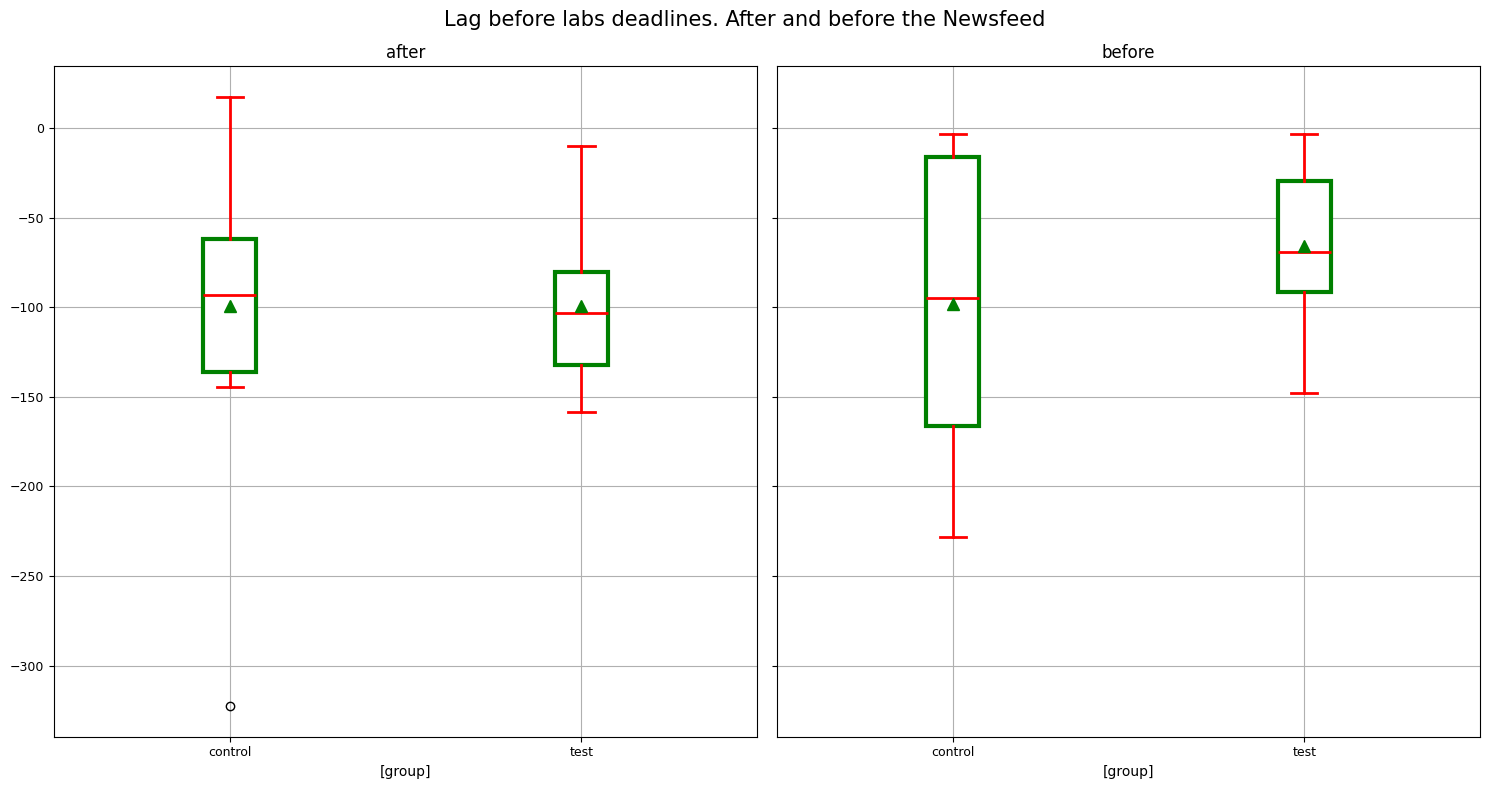

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8), sharey=True)
fig.suptitle(
    'Lag before labs deadlines. After and before the Newsfeed',
    fontsize=15,
)

for plot, period in zip(axes, ['after', 'before']):
    values = [data[period]['control'], data[period]['test']]
    labels = ['control', 'test']

    bp = plot.boxplot(
        values,
        tick_labels=labels,
        patch_artist=True,
        showmeans=True,
        boxprops=BOXPROPS,
        whiskerprops=WHISKERPROPS,
        capprops=CAPPROPS,
        medianprops=MEDIANPROPS,
        meanprops=MEANPROPS
    )

    plot.set_title(period, fontsize=12)
    plot.set_xlabel('[group]', fontsize=10)
    plot.grid(True)
    plot.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

## "What was the IQR of the control group before the newsfeed?" In your answer, provide an approximate value that can be obtained simply by looking at the graph and round it to the nearest 10.

In [6]:
iqr_before_control = data['before']['control'].quantile(0.75) - data['before']['control'].quantile(0.25)
print(f"{iqr_before_control:.0f}")

150
